<a href="https://colab.research.google.com/github/fathimanoorjahan03-afk/intermediate_assessment_2/blob/main/intermediate_assessment_2_FathimaN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HR Analytics — Employee Promotion Prediction

## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/DSA/Hackathon Assessment/train_LZdllcl.csv')
test = pd.read_csv('/content/drive/MyDrive/DSA/Hackathon Assessment/test_2umaH9m.csv')
sample_submission = pd.read_csv('/content/drive/MyDrive/DSA/Hackathon Assessment/sample_submission_M0L0uXE.csv')

In [ ]:
print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Sample submission shape:', sample_submission.shape)

Train shape: (54808, 14)
Test shape: (23490, 13)
Sample submission shape: (23490, 2)


## Initial Data Validation

In [ ]:
print('Train columns:')
print(train.columns.tolist())

print('Test columns:')
print(test.columns.tolist())

Train columns:
['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score', 'is_promoted']
Test columns:
['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score']


In [ ]:
train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [ ]:
train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


## Exploratory Data Analysis (EDA)

In [ ]:
train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [ ]:
train.isnull().mean() * 100

,0
employee_id,0.000000
department,0.000000
region,0.000000
education,4.395344
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.524449
length_of_service,0.000000


In [ ]:
train.nunique()

,0
employee_id,54808
department,9
region,34
education,3
gender,2
recruitment_channel,3
no_of_trainings,10
age,41
previous_year_rating,5
length_of_service,35


In [ ]:
train['is_promoted'].value_counts()

,count
is_promoted,
0,50140
1,4668


In [ ]:
train['is_promoted'].value_counts(normalize=True) * 100

,proportion
is_promoted,
0,91.482995
1,8.517005


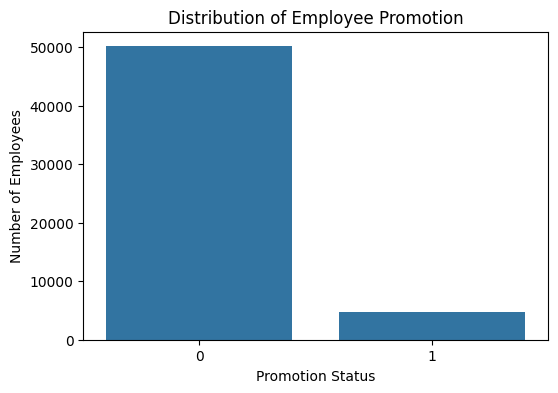

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x='is_promoted')
plt.title('Distribution of Employee Promotion')
plt.xlabel('Promotion Status')
plt.ylabel('Number of Employees')
plt.show()

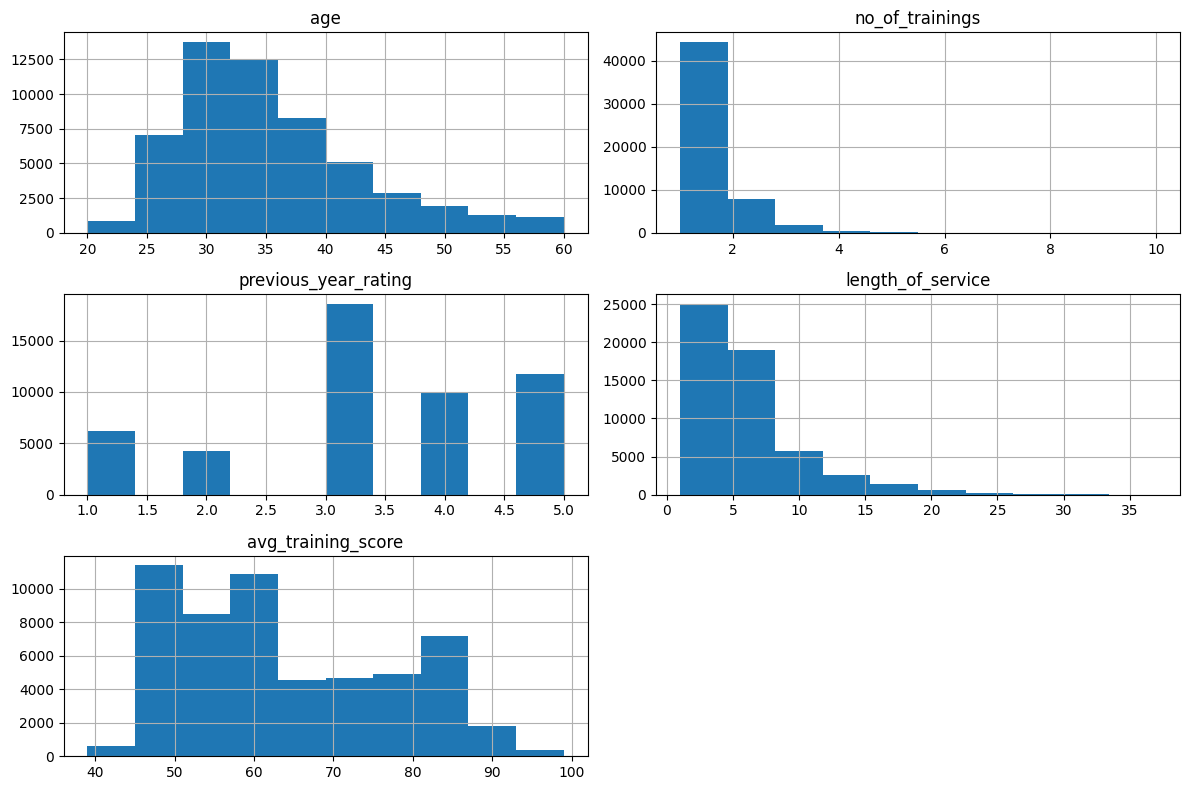

In [ ]:
train[['age', 'no_of_trainings', 'previous_year_rating',
       'length_of_service', 'avg_training_score']].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [ ]:
train.groupby('previous_year_rating')['is_promoted'].mean() * 100

,is_promoted
previous_year_rating,
1.0,1.414109
2.0,4.284024
3.0,7.277903
4.0,7.937633
5.0,16.361468


In [ ]:
train.groupby('KPIs_met >80%')['is_promoted'].mean() * 100

,is_promoted
KPIs_met >80%,
0,3.958668
1,16.909440


In [ ]:
train.groupby('awards_won?')['is_promoted'].mean() * 100

,is_promoted
awards_won?,
0,7.674922
1,44.015748


In [ ]:
train.groupby('department')['is_promoted'].mean().sort_values(ascending=False) * 100

,is_promoted
department,
Technology,10.759316
Procurement,9.638554
Analytics,9.566517
Operations,9.014804
Finance,8.123028
Sales & Marketing,7.203088
R&D,6.906907
HR,5.624483
Legal,5.101059


In [ ]:
train.groupby('education', dropna=False)['is_promoted'].mean() * 100

,is_promoted
education,
Bachelor's,8.203114
Below Secondary,8.322981
Master's & above,9.855946
NaN,5.064342


In [ ]:
train.groupby('recruitment_channel')['is_promoted'].mean().sort_values(ascending=False) * 100

,is_promoted
recruitment_channel,
referred,12.084063
sourcing,8.501292
other,8.395191


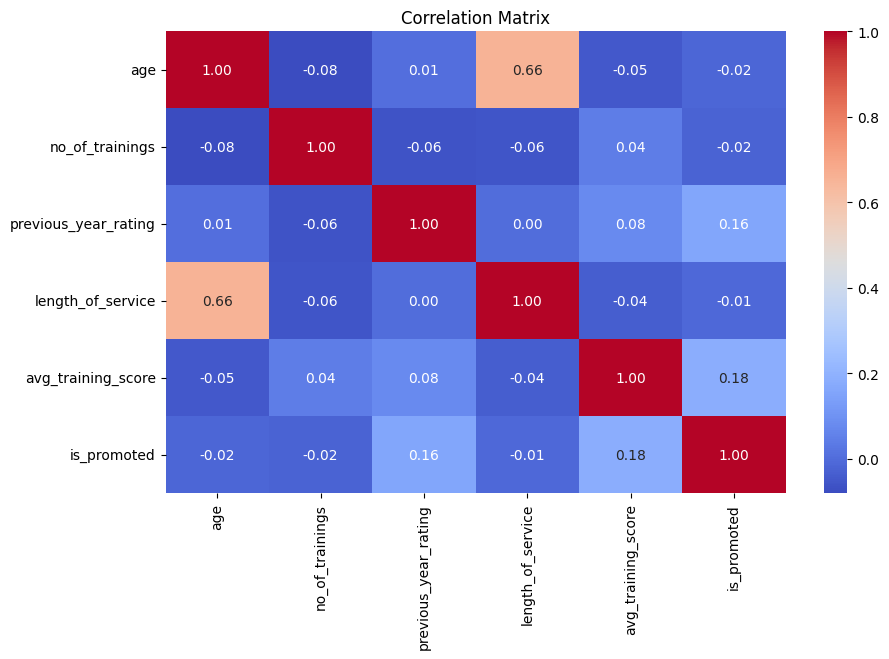

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    train[['age', 'no_of_trainings', 'previous_year_rating',
           'length_of_service', 'avg_training_score', 'is_promoted']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

### EDA Findings

- The target is highly imbalanced, with promotion representing a small minority of observations.
- Missing values occur in `education` and `previous_year_rating`
- `KPIs_met >80%`, `awards_won?`, `previous_year_rating`, `avg_training_score`, and department show useful relationships with promotion.
- `employee_id` is an identifier and is not used as a model feature.
- No training rows are removed.

In [ ]:
# Define features and target
X = train.drop(columns='is_promoted')
y = train['is_promoted']

X = X.drop(columns='employee_id')

In [ ]:
#vTrain/Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print('Numerical columns:', list(numeric_cols))
print('Categorical columns:', list(categorical_cols))

Numerical columns: ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score']
Categorical columns: ['department', 'region', 'education', 'gender', 'recruitment_channel']


## Pre-processing Pipeline

In [ ]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

## Logistic Regression

In [ ]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [ ]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPIs_met >80%', 'awards_won?', 'avg_training_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred_lr = lr_model.predict(X_val)
y_prob_lr = lr_model.predict_proba(X_val)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_val, y_pred_lr))
print("Precision:", precision_score(y_val, y_pred_lr))
print("Recall:", recall_score(y_val, y_pred_lr))
print("F1 Score:", f1_score(y_val, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_lr))

Accuracy: 0.7662835249042146
Precision: 0.24256799493991144
Recall: 0.8211991434689507
F1 Score: 0.37451171875
ROC-AUC: 0.8766548952013591


## Decision Tree

In [ ]:
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42
    ))
])

In [ ]:
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPIs_met >80%', 'awards_won?', 'avg_training_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_split=10,
                                        random_state=42))])

In [ ]:
y_pred_dt = dt_model.predict(X_val)
y_prob_dt = dt_model.predict_proba(X_val)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_val, y_pred_dt))
print("Precision:", precision_score(y_val, y_pred_dt))
print("Recall:", recall_score(y_val, y_pred_dt))
print("F1 Score:", f1_score(y_val, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_dt))

Accuracy: 0.7040686006203247
Precision: 0.21081622433650477
Recall: 0.9014989293361885
F1 Score: 0.3417207792207792
ROC-AUC: 0.8737910723635491


## Random Forest

In [ ]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])


In [ ]:
rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPIs_met >80%', 'awards_won?', 'avg_training_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_split=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [ ]:
y_pred_rf = rf_model.predict(X_val)
y_prob_rf = rf_model.predict_proba(X_val)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Precision:", precision_score(y_val, y_pred_rf))
print("Recall:", recall_score(y_val, y_pred_rf))
print("F1 Score:", f1_score(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_rf))

Accuracy: 0.7298850574712644
Precision: 0.21682034087734003
Recall: 0.8308351177730193
F1 Score: 0.34389541325060935
ROC-AUC: 0.8705944554391174


## Gradient Boosting

In [ ]:
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [ ]:
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPIs_met >80%', 'awards_won?', 'avg_training_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=150,
                                            random_state=42))])

In [ ]:
y_pred_gb = gb_model.predict(X_val)
y_prob_gb = gb_model.predict_proba(X_val)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_val, y_pred_gb))
print("Precision:", precision_score(y_val, y_pred_gb))
print("Recall:", recall_score(y_val, y_pred_gb))
print("F1 Score:", f1_score(y_val, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_gb))

Accuracy: 0.9373289545703338
Precision: 0.9920318725099602
Recall: 0.26659528907922914
F1 Score: 0.42025316455696204
ROC-AUC: 0.9020511838799967


## Baseline Models Comparison

In [ ]:
results = []

models_predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
}

for model_name, predictions in models_predictions.items():

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_val, predictions),
        'Precision': precision_score(y_val, predictions),
        'Recall': recall_score(y_val, predictions),
        'F1 Score': f1_score(y_val, predictions)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.937329,0.992032,0.266595,0.420253
1,Logistic Regression,0.766284,0.242568,0.821199,0.374512
2,Random Forest,0.729885,0.216820,0.830835,0.343895
3,Decision Tree,0.704069,0.210816,0.901499,0.341721


## Hyperparameter fine-tuning

In [ ]:
param_grid = {
    'model__n_estimators': [100, 150, 200],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    gb_model,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation F1:', grid_search.best_score_)

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}
Best cross-validation F1: 0.49700967961779474


In [ ]:
y_pred_tuned = grid_search.predict(X_val)
y_prob_tuned = grid_search.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, y_pred_tuned))
print("Precision:", precision_score(y_val, y_pred_tuned))
print("Recall:", recall_score(y_val, y_pred_tuned))
print("F1 Score:", f1_score(y_val, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_tuned))

Accuracy: 0.9426199598613392
Precision: 0.9498525073746312
Recall: 0.34475374732334046
F1 Score: 0.5058915946582875
ROC-AUC: 0.9114593698671557


## Classification Threshold Tuning

In [ ]:
threshold_results = []

for threshold in np.arange(0.10, 0.51, 0.01):
    y_pred_threshold = (y_prob_tuned >= threshold).astype(int)
    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Precision': precision_score(y_val, y_pred_threshold),
        'Recall': recall_score(y_val, y_pred_threshold),
        'F1': f1_score(y_val, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)
threshold_results.sort_values('F1', ascending=False).head(10)

,Threshold,Precision,Recall,F1
15,0.25,0.636364,0.457173,0.532087
16,0.26,0.660828,0.444325,0.531370
14,0.24,0.604651,0.473233,0.530931
17,0.27,0.682968,0.433619,0.530452
13,0.23,0.576293,0.489293,0.529241
19,0.29,0.738878,0.408994,0.526533
21,0.31,0.776151,0.397216,0.525496
23,0.33,0.815315,0.387580,0.525399
22,0.32,0.800439,0.390792,0.525180
18,0.28,0.706522,0.417559,0.524899


In [ ]:
best_threshold = threshold_results.loc[threshold_results['F1'].idxmax(), 'Threshold']
print('Best threshold:', best_threshold)

Best threshold: 0.25


In [ ]:
y_pred_threshold = (y_prob_tuned >= best_threshold).astype(int)

print('Accuracy:', accuracy_score(y_val, y_pred_threshold))
print('Precision:', precision_score(y_val, y_pred_threshold))
print('Recall:', recall_score(y_val, y_pred_threshold))
print('F1 Score:', f1_score(y_val, y_pred_threshold))
print('ROC-AUC:', roc_auc_score(y_val, y_prob_tuned))

Accuracy: 0.931490603904397
Precision: 0.6363636363636364
Recall: 0.45717344753747324
F1 Score: 0.5320872274143302
ROC-AUC: 0.9114593698671557


## final model evaluation

              precision    recall  f1-score   support

           0     0.9507    0.9757    0.9630     10028
           1     0.6364    0.4572    0.5321       934

    accuracy                         0.9315     10962
   macro avg     0.7935    0.7164    0.7476     10962
weighted avg     0.9239    0.9315    0.9263     10962

Confusion Matrix:
[[9784  244]
 [ 507  427]]


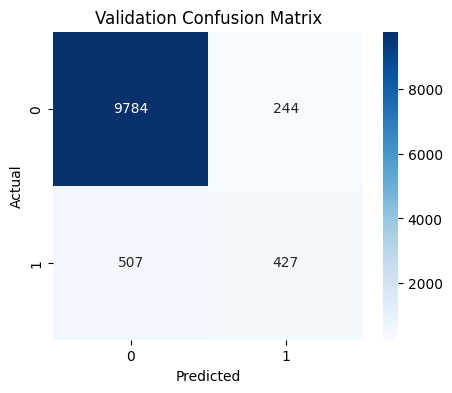

In [ ]:
print(classification_report(y_val, y_pred_threshold, digits=4))

cm = confusion_matrix(y_val, y_pred_threshold)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Final model selection

In [ ]:
final_model = grid_search.best_estimator_
final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPIs_met >80%', 'awards_won?', 'avg_training_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [ ]:
X_test = test.drop(columns='employee_id')

print('Test feature shape:', X_test.shape)
print('Feature columns match:', list(X.columns) == list(X_test.columns))

Test feature shape: (23490, 12)
Feature columns match: True


In [ ]:
test_prob = final_model.predict_proba(X_test)[:, 1]
test_predictions = (test_prob >= best_threshold).astype(int)

print('Predicted promotions:', test_predictions.sum())
print('Predicted non-promotions:', (test_predictions == 0).sum())

Predicted promotions: 1334
Predicted non-promotions: 22156


In [ ]:
submission = sample_submission.copy()
submission['is_promoted'] = test_predictions

submission.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [ ]:
print('Shape:', submission.shape)
print('Missing values:', submission.isnull().sum().sum())
print('Duplicate IDs:', submission['employee_id'].duplicated().sum())
print('Unique IDs:', submission['employee_id'].nunique())
print('Expected test rows:', len(test))
print('Prediction values:', sorted(submission['is_promoted'].unique()))

Shape: (23490, 2)
Missing values: 0
Duplicate IDs: 0
Unique IDs: 23490
Expected test rows: 23490
Prediction values: [np.int64(0), np.int64(1)]


In [ ]:
assert submission.shape == (len(test), 2)
assert submission['employee_id'].nunique() == len(test)
assert submission.isnull().sum().sum() == 0
assert set(submission['is_promoted'].unique()).issubset({0, 1})
assert submission['employee_id'].equals(sample_submission['employee_id'])

print('Submission validation passed.')

Submission validation passed.


In [ ]:
submission_path = f'/content/drive/MyDrive/DSA/Hackathon Assessment/final_submission.csv'
submission.to_csv(submission_path, index=False)
print('Saved to:', submission_path)

Saved to: /content/drive/MyDrive/DSA/Hackathon Assessment/final_submission.csv


## Final model summary

In [ ]:
print('Final model: Gradient Boosting')
print('Best parameters:', grid_search.best_params_)
print('Selected threshold:', best_threshold)
print('Validation F1:', round(f1_score(y_val, y_pred_threshold), 4))
print('Validation ROC-AUC:', round(roc_auc_score(y_val, y_prob_tuned), 4))
print('Submission rows:', len(submission))
print('Submission file:', submission_path)

Final model: Gradient Boosting
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}
Selected threshold: 0.25
Validation F1: 0.5321
Validation ROC-AUC: 0.9115
Submission rows: 23490
Submission file: /content/drive/MyDrive/DSA/Hackathon Assessment/final_submission.csv


## Conclusion

- **EDA:** Identified an imbalanced target variable `is_promoted`, missing values in `education` and `previous_year_rating`, and key features influencing promotion `KPIs_met >80%`, `awards_won?`, `previous_year_rating`, `avg_training_score`, and `department`.

- **Preprocessing:** Numerical features were imputed with the median, and categorical features were imputed with the most frequent value and one-hot encoded.

- **Model Comparison:** Evaluated Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Gradient Boosting showed the best performance among the baseline models.

- **Hyperparameter Tuning:** Tuned the Gradient Boosting model using `GridSearchCV` and found optimal parameters, improving the F1 score on the validation set.

- **Threshold Optimization:** Further refined the model by optimizing the classification threshold, leading to a balanced precision and recall, and an improved F1 score.

- **Final Model:** The tuned Gradient Boosting model with an optimized threshold was used to make predictions on the test set, and the submission file was generated and validated.

In [ ]:
# Create a separate submission using threshold 0.25

alternative_threshold = 0.25

test_predictions_025 = (test_prob >= alternative_threshold).astype(int)

submission_025 = sample_submission.copy()
submission_025['is_promoted'] = test_predictions_025

submission_025_path = f'/content/drive/MyDrive/DSA/Hackathon Assessment/submission_threshold_025.csv'
submission_025.to_csv(submission_025_path, index=False)

print("Submission created successfully.")
print("Threshold:", alternative_threshold)
print("File:", submission_025_path)
print("Shape:", submission_025.shape)

Submission created successfully.
Threshold: 0.25
File: /content/drive/MyDrive/DSA/Hackathon Assessment/submission_threshold_025.csv
Shape: (23490, 2)


In [ ]:
# Check the validation thresholds with the highest F1 scores

threshold_results.sort_values(
    by='F1',
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
15,0.25,0.636364,0.457173,0.532087
16,0.26,0.660828,0.444325,0.531370
14,0.24,0.604651,0.473233,0.530931
17,0.27,0.682968,0.433619,0.530452
13,0.23,0.576293,0.489293,0.529241
19,0.29,0.738878,0.408994,0.526533
21,0.31,0.776151,0.397216,0.525496
23,0.33,0.815315,0.387580,0.525399
22,0.32,0.800439,0.390792,0.525180
18,0.28,0.706522,0.417559,0.524899


In [ ]:
!pip install -q xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [ ]:
# Evaluate XGBoost on the validation set

y_pred_xgb = xgb_model.predict(X_val)
y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

print("XGBoost Validation Results")
print("Accuracy :", accuracy_score(y_val, y_pred_xgb))
print("Precision:", precision_score(y_val, y_pred_xgb))
print("Recall   :", recall_score(y_val, y_pred_xgb))
print("F1 Score :", f1_score(y_val, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_val, y_prob_xgb))

XGBoost Validation Results
Accuracy : 0.9426199598613392
Precision: 0.9750778816199377
Recall   : 0.3351177730192719
F1 Score : 0.49880478087649405
ROC-AUC  : 0.9115670982063926


In [ ]:
xgb_thresholds = np.arange(0.10, 0.51, 0.01)

xgb_threshold_results = []

for threshold in xgb_thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    xgb_threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_val, y_pred_threshold, zero_division=0),
        'Recall': recall_score(y_val, y_pred_threshold, zero_division=0),
        'F1': f1_score(y_val, y_pred_threshold, zero_division=0)
    })

xgb_threshold_results = pd.DataFrame(xgb_threshold_results)

xgb_threshold_results.sort_values(
    by='F1',
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
15,0.25,0.675241,0.449679,0.539846
16,0.26,0.702091,0.431478,0.534483
17,0.27,0.728281,0.421842,0.534237
14,0.24,0.624820,0.463597,0.532268
18,0.28,0.760956,0.408994,0.532033
20,0.30,0.807860,0.396146,0.531609
21,0.31,0.834862,0.389722,0.531387
19,0.29,0.782427,0.400428,0.529745
22,0.32,0.845606,0.381156,0.525461
23,0.33,0.864865,0.376874,0.524981


In [ ]:
# Create XGBoost submission using the best validation threshold

xgb_best_threshold = 0.25

test_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
test_predictions_xgb = (test_prob_xgb >= xgb_best_threshold).astype(int)

submission_xgb = sample_submission.copy()
submission_xgb['is_promoted'] = test_predictions_xgb

xgb_submission_path = f'/content/drive/MyDrive/DSA/Hackathon Assessment/submission_xgb_025.csv'
submission_xgb.to_csv(xgb_submission_path, index=False)

print("XGBoost submission created successfully.")
print("Threshold:", xgb_best_threshold)
print("Shape:", submission_xgb.shape)
print("File:", xgb_submission_path)

XGBoost submission created successfully.
Threshold: 0.25
Shape: (23490, 2)
File: /content/drive/MyDrive/DSA/Hackathon Assessment/submission_xgb_025.csv


In [ ]:
!pip install -q lightgbm

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        verbosity=-1
    ))
])

lgbm_model.fit(X_train, y_train)

print("LightGBM model trained successfully.")

LightGBM model trained successfully.


In [ ]:
# Evaluate LightGBM on the validation set

y_pred_lgbm = lgbm_model.predict(X_val)
y_prob_lgbm = lgbm_model.predict_proba(X_val)[:, 1]

print("LightGBM Validation Results")
print("---------------------------")
print("Accuracy :", accuracy_score(y_val, y_pred_lgbm))
print("Precision:", precision_score(y_val, y_pred_lgbm))
print("Recall   :", recall_score(y_val, y_pred_lgbm))
print("F1 Score :", f1_score(y_val, y_pred_lgbm))
print("ROC-AUC  :", roc_auc_score(y_val, y_prob_lgbm))

LightGBM Validation Results
---------------------------
Accuracy : 0.9436234263820471
Precision: 0.9730538922155688
Recall   : 0.34796573875803
F1 Score : 0.5126182965299685
ROC-AUC  : 0.9145074199094784


In [ ]:
lgbm_thresholds = np.arange(0.10, 0.51, 0.01)

lgbm_threshold_results = []

for threshold in lgbm_thresholds:
    y_pred_threshold = (y_prob_lgbm >= threshold).astype(int)

    lgbm_threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_val, y_pred_threshold, zero_division=0),
        'Recall': recall_score(y_val, y_pred_threshold, zero_division=0),
        'F1': f1_score(y_val, y_pred_threshold, zero_division=0)
    })

lgbm_threshold_results = pd.DataFrame(lgbm_threshold_results)

lgbm_threshold_results.sort_values(
    by='F1',
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
15,0.25,0.648649,0.462527,0.540000
16,0.26,0.675241,0.449679,0.539846
23,0.33,0.859485,0.392934,0.539309
17,0.27,0.700516,0.435760,0.537294
19,0.29,0.761811,0.414347,0.536755
22,0.32,0.838269,0.394004,0.536052
20,0.30,0.787942,0.405782,0.535689
24,0.34,0.866029,0.387580,0.535503
25,0.35,0.883951,0.383298,0.534727
14,0.24,0.608219,0.475375,0.533654


In [ ]:
# Create LightGBM submission using the best validation threshold

lgbm_best_threshold = 0.25

test_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
test_predictions_lgbm = (test_prob_lgbm >= lgbm_best_threshold).astype(int)

submission_lgbm = sample_submission.copy()
submission_lgbm['is_promoted'] = test_predictions_lgbm

lgbm_submission_path = f'/content/drive/MyDrive/DSA/Hackathon Assessment/submission_lgbm_025.csv'
submission_lgbm.to_csv(lgbm_submission_path, index=False)

print("LightGBM submission created successfully.")
print("Threshold:", lgbm_best_threshold)
print("Shape:", submission_lgbm.shape)
print("File:", lgbm_submission_path)

LightGBM submission created successfully.
Threshold: 0.25
Shape: (23490, 2)
File: /content/drive/MyDrive/DSA/Hackathon Assessment/submission_lgbm_025.csv


In [ ]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

# Remove employee_id because it is only an identifier
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()

categorical_features = [
    'department',
    'region',
    'education',
    'gender',
    'recruitment_channel'
]

# Convert categorical columns to strings so CatBoost can handle missing values
for col in categorical_features:
    X_train_cat[col] = X_train_cat[col].fillna('Missing').astype(str)
    X_val_cat[col] = X_val_cat[col].fillna('Missing').astype(str)

print("CatBoost data prepared.")
print("Training shape:", X_train_cat.shape)
print("Validation shape:", X_val_cat.shape)

CatBoost data prepared.
Training shape: (43846, 12)
Validation shape: (10962, 12)


In [ ]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train_cat,
    y_train,
    cat_features=categorical_features
)

print("CatBoost model trained successfully.")

CatBoost model trained successfully.


In [ ]:
# Evaluate CatBoost on the validation set

y_pred_cat = catboost_model.predict(X_val_cat).astype(int).ravel()
y_prob_cat = catboost_model.predict_proba(X_val_cat)[:, 1]

print("CatBoost Validation Results")
print("--------------------------")
print("Accuracy :", accuracy_score(y_val, y_pred_cat))
print("Precision:", precision_score(y_val, y_pred_cat))
print("Recall   :", recall_score(y_val, y_pred_cat))
print("F1 Score :", f1_score(y_val, y_pred_cat))
print("ROC-AUC  :", roc_auc_score(y_val, y_prob_cat))

CatBoost Validation Results
--------------------------
Accuracy : 0.9431673052362708
Precision: 0.9587020648967551
Recall   : 0.34796573875803
F1 Score : 0.5106048703849175
ROC-AUC  : 0.914418108952321


In [ ]:
cat_thresholds = np.arange(0.10, 0.51, 0.01)

cat_threshold_results = []

for threshold in cat_thresholds:
    y_pred_threshold = (y_prob_cat >= threshold).astype(int)

    cat_threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_val, y_pred_threshold, zero_division=0),
        'Recall': recall_score(y_val, y_pred_threshold, zero_division=0),
        'F1': f1_score(y_val, y_pred_threshold, zero_division=0)
    })

cat_threshold_results = pd.DataFrame(cat_threshold_results)

cat_threshold_results.sort_values(
    by='F1',
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
19,0.29,0.758285,0.416488,0.537664
16,0.26,0.689597,0.440043,0.537255
18,0.28,0.735075,0.421842,0.536054
15,0.25,0.660911,0.450749,0.535964
17,0.27,0.704745,0.429336,0.533599
14,0.24,0.625360,0.464668,0.533170
11,0.21,0.535135,0.529979,0.532544
20,0.30,0.777778,0.404711,0.532394
12,0.22,0.566425,0.502141,0.532350
21,0.31,0.800000,0.398287,0.531808


In [ ]:
# Create blended validation probabilities

blend_prob = (
    0.25 * y_prob_tuned +
    0.25 * y_prob_xgb +
    0.25 * y_prob_lgbm +
    0.25 * y_prob_cat
)

print("Blended validation probabilities created.")

Blended validation probabilities created.


In [ ]:
blend_thresholds = np.arange(0.10, 0.51, 0.01)

blend_threshold_results = []

for threshold in blend_thresholds:
    y_pred_blend = (blend_prob >= threshold).astype(int)

    blend_threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_val, y_pred_blend, zero_division=0),
        'Recall': recall_score(y_val, y_pred_blend, zero_division=0),
        'F1': f1_score(y_val, y_pred_blend, zero_division=0)
    })

blend_threshold_results = pd.DataFrame(blend_threshold_results)

blend_threshold_results.sort_values(
    by='F1',
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
18,0.28,0.759690,0.419700,0.540690
19,0.29,0.784114,0.412206,0.540351
17,0.27,0.722523,0.429336,0.538617
20,0.30,0.794979,0.406852,0.538244
16,0.26,0.683775,0.442184,0.537061
15,0.25,0.653846,0.455032,0.536616
13,0.23,0.591731,0.490364,0.536300
22,0.32,0.841743,0.392934,0.535766
21,0.31,0.815789,0.398287,0.535252
14,0.24,0.628613,0.465739,0.535055


In [ ]:
# Create test probabilities for CatBoost

X_test_cat = X_test.copy()

for col in categorical_features:
    X_test_cat[col] = X_test_cat[col].fillna('Missing').astype(str)

test_prob_cat = catboost_model.predict_proba(X_test_cat)[:, 1]

print("CatBoost test probabilities created.")

CatBoost test probabilities created.


In [ ]:
test_prob_gb = final_model.predict_proba(X_test)[:, 1]
test_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
test_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

test_prob_blend = (
    0.25 * test_prob_gb +
    0.25 * test_prob_xgb +
    0.25 * test_prob_lgbm +
    0.25 * test_prob_cat
)

print("Test blend probabilities created.")
print("Number of predictions:", len(test_prob_blend))

Test blend probabilities created.
Number of predictions: 23490


In [ ]:
blend_threshold = 0.28

test_pred_blend = (test_prob_blend >= blend_threshold).astype(int)

submission_blend = sample_submission.copy()
submission_blend['is_promoted'] = test_pred_blend

submission_blend.to_csv(
    '/content/drive/MyDrive/DSA/Hackathon Assessment/submission_blend_028.csv',
    index=False
)

print("Submission created successfully.")
print("Shape:", submission_blend.shape)
print("Predicted promotions:", test_pred_blend.sum())
print("Saved as: submission_blend_028.csv")

Submission created successfully.
Shape: (23490, 2)
Predicted promotions: 1035
Saved as: submission_blend_028.csv


In [ ]:
print(submission_blend.head())
print("\nShape:", submission_blend.shape)
print("\nColumns:", submission_blend.columns.tolist())
print("\nMissing values:")
print(submission_blend.isnull().sum())
print("\nPrediction counts:")
print(submission_blend['is_promoted'].value_counts())

   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0

Shape: (23490, 2)

Columns: ['employee_id', 'is_promoted']

Missing values:
employee_id    0
is_promoted    0
dtype: int64

Prediction counts:
is_promoted
0    22455
1     1035
Name: count, dtype: int64
